In [18]:
# Import Required Libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import warnings
warnings.filterwarnings('ignore')

In [19]:
# Load the Heart Disease Dataset
df = pd.read_csv('../data/heart.csv')

print("Dataset Shape:", df.shape)
print("\nFirst 5 rows:")
print(df.head())
print("\nDataset Info:")
print(df.info())
print("\nDataset Description:")
print(df.describe())

Dataset Shape: (1025, 14)

First 5 rows:
   age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  slope  \
0   52    1   0       125   212    0        1      168      0      1.0      2   
1   53    1   0       140   203    1        0      155      1      3.1      0   
2   70    1   0       145   174    0        1      125      1      2.6      0   
3   61    1   0       148   203    0        1      161      0      0.0      2   
4   62    0   0       138   294    1        1      106      0      1.9      1   

   ca  thal  target  
0   2     3       0  
1   0     3       0  
2   0     3       0  
3   1     3       0  
4   3     2       0  

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non

In [20]:
# Check for Missing Values and Duplicates
print("Missing Values:")
print(df.isnull().sum())
print("\nDuplicate Rows:", df.duplicated().sum())
print("\nTarget Distribution:")
print(df['target'].value_counts())
print("\nTarget Percentage:")
print(df['target'].value_counts(normalize=True) * 100)

Missing Values:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

Duplicate Rows: 723

Target Distribution:
target
1    526
0    499
Name: count, dtype: int64

Target Percentage:
target
1    51.317073
0    48.682927
Name: proportion, dtype: float64


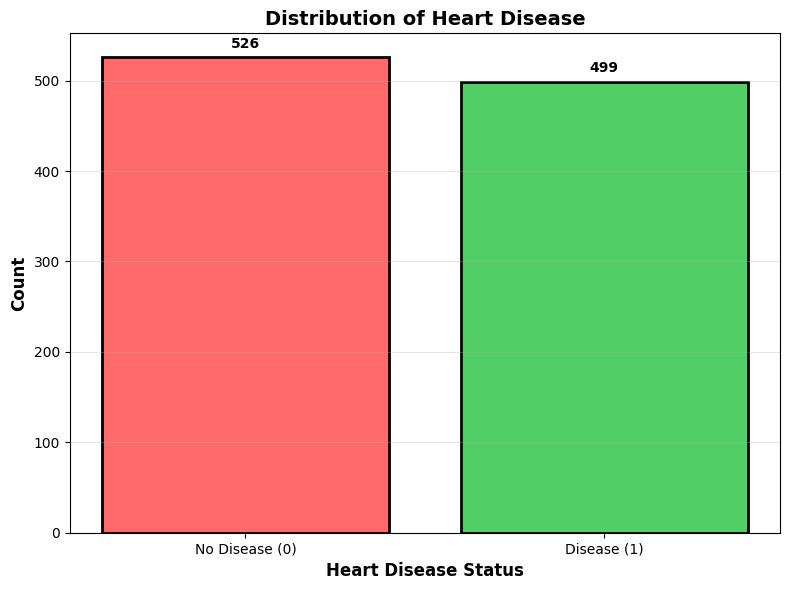

In [21]:
# Visualization 1: Distribution of Target (Heart Disease)
plt.figure(figsize=(8, 6))
target_counts = df['target'].value_counts()
colors = ['#ff6b6b', '#51cf66']
plt.bar(['No Disease (0)', 'Disease (1)'], target_counts.values, color=colors, edgecolor='black', linewidth=2)
plt.xlabel('Heart Disease Status', fontsize=12, fontweight='bold')
plt.ylabel('Count', fontsize=12, fontweight='bold')
plt.title('Distribution of Heart Disease', fontsize=14, fontweight='bold')
plt.grid(axis='y', alpha=0.3)
for i, v in enumerate(target_counts.values):
    plt.text(i, v + 10, str(v), ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

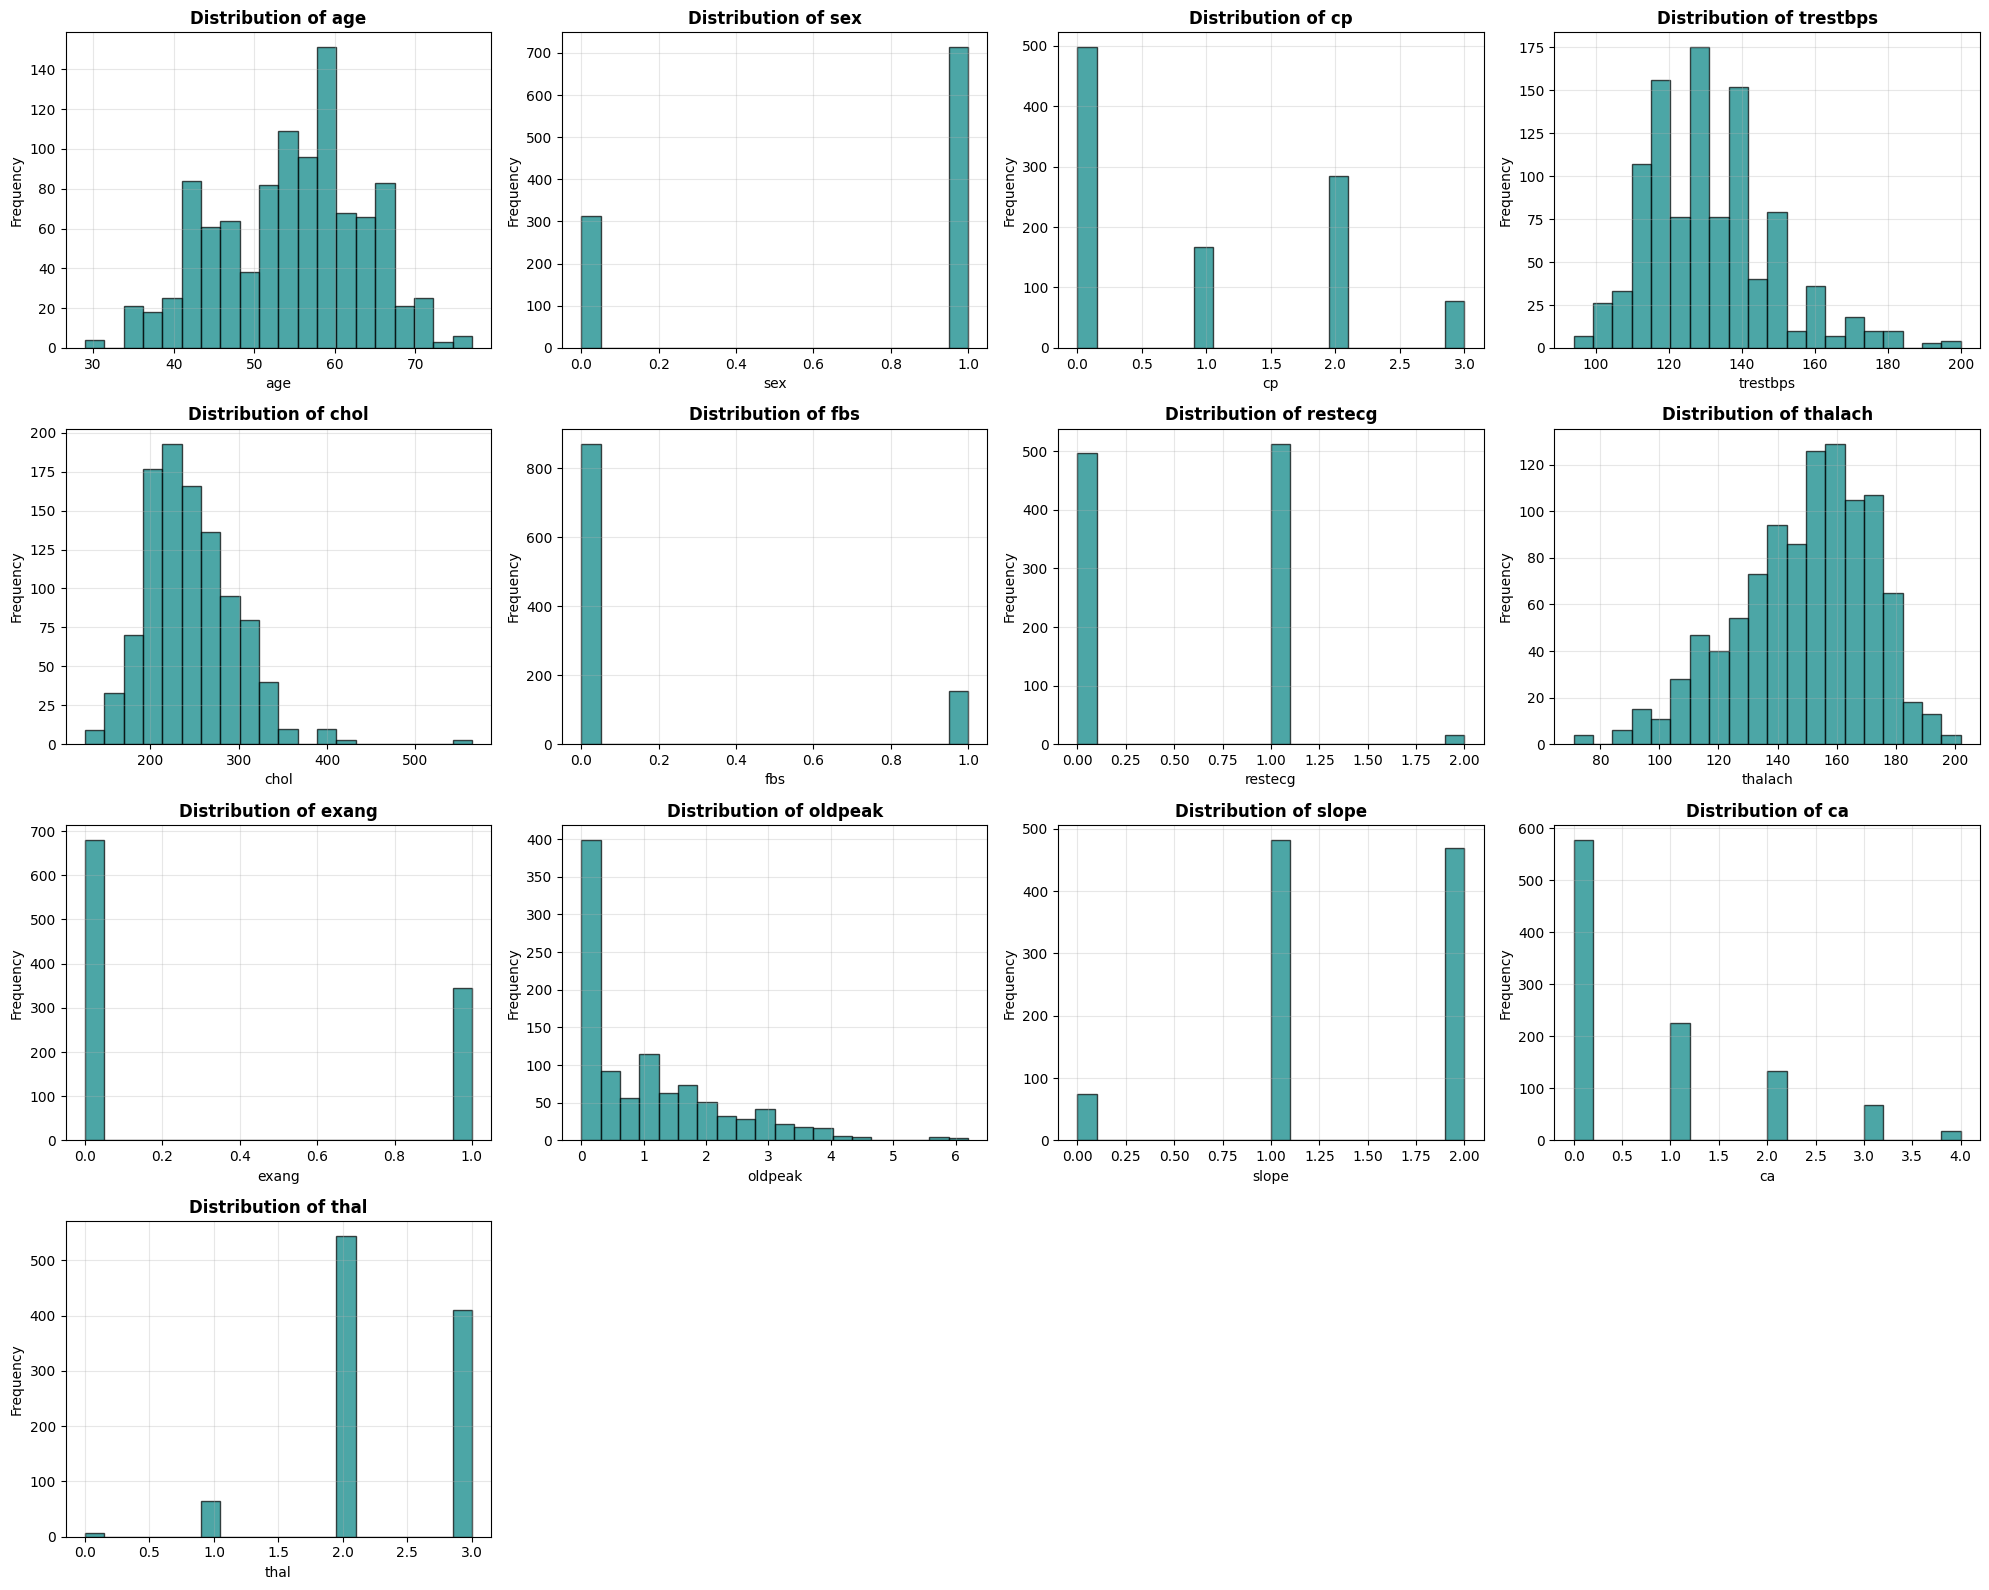

In [22]:
# Visualization 2: Feature Distributions
fig, axes = plt.subplots(4, 4, figsize=(20, 16))
features = ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 
            'exang', 'oldpeak', 'slope', 'ca', 'thal']

for idx, feature in enumerate(features):
    row = idx // 4
    col = idx % 4
    axes[row, col].hist(df[feature], bins=20, color='teal', edgecolor='black', alpha=0.7)
    axes[row, col].set_title(f'Distribution of {feature}', fontweight='bold')
    axes[row, col].set_xlabel(feature)
    axes[row, col].set_ylabel('Frequency')
    axes[row, col].grid(alpha=0.3)

# Remove empty subplots
fig.delaxes(axes[3, 1])
fig.delaxes(axes[3, 2])
fig.delaxes(axes[3, 3])
plt.tight_layout()
plt.show()

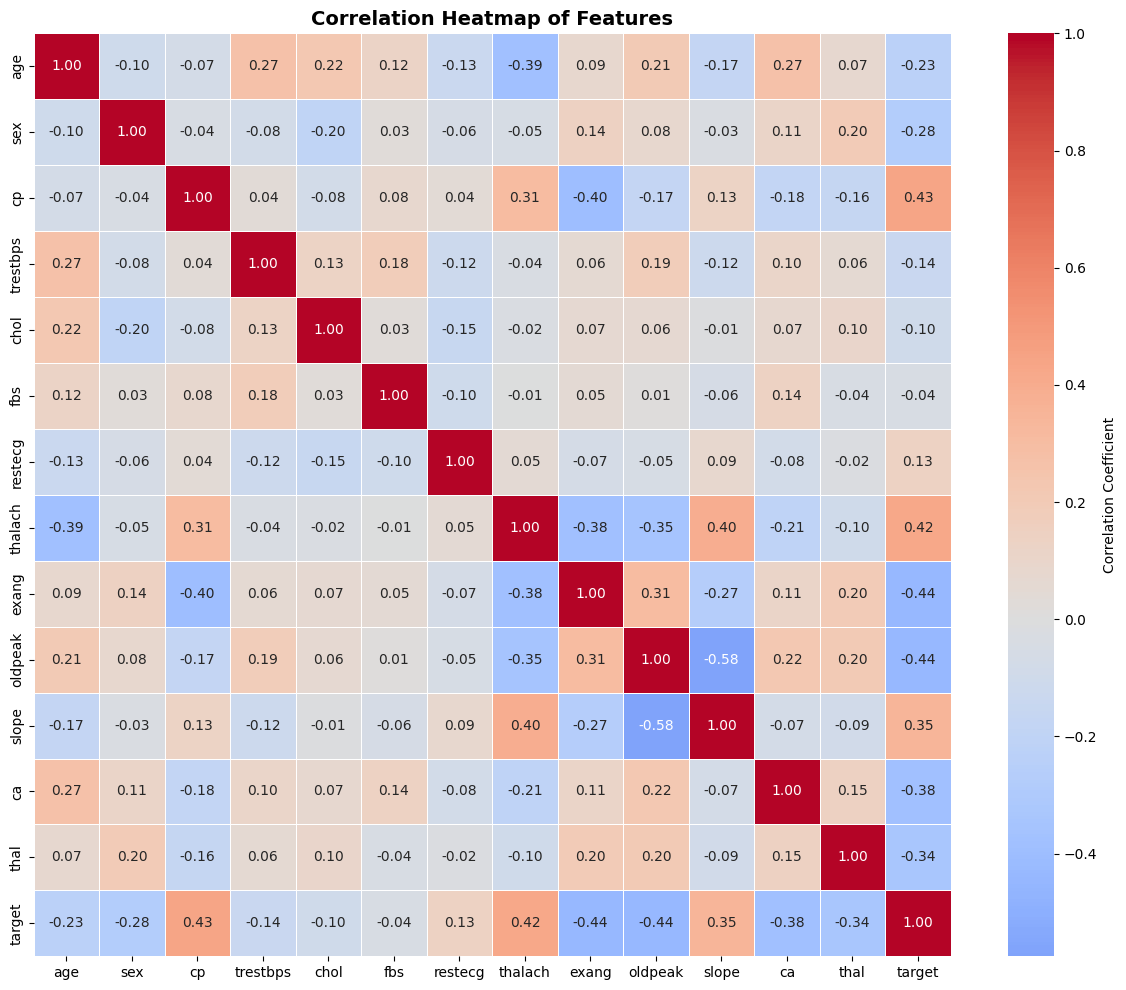

In [23]:
# Visualization 3: Correlation Heatmap
plt.figure(figsize=(12, 10))
correlation_matrix = df.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5, 
            cbar_kws={'label': 'Correlation Coefficient'}, center=0)
plt.title('Correlation Heatmap of Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

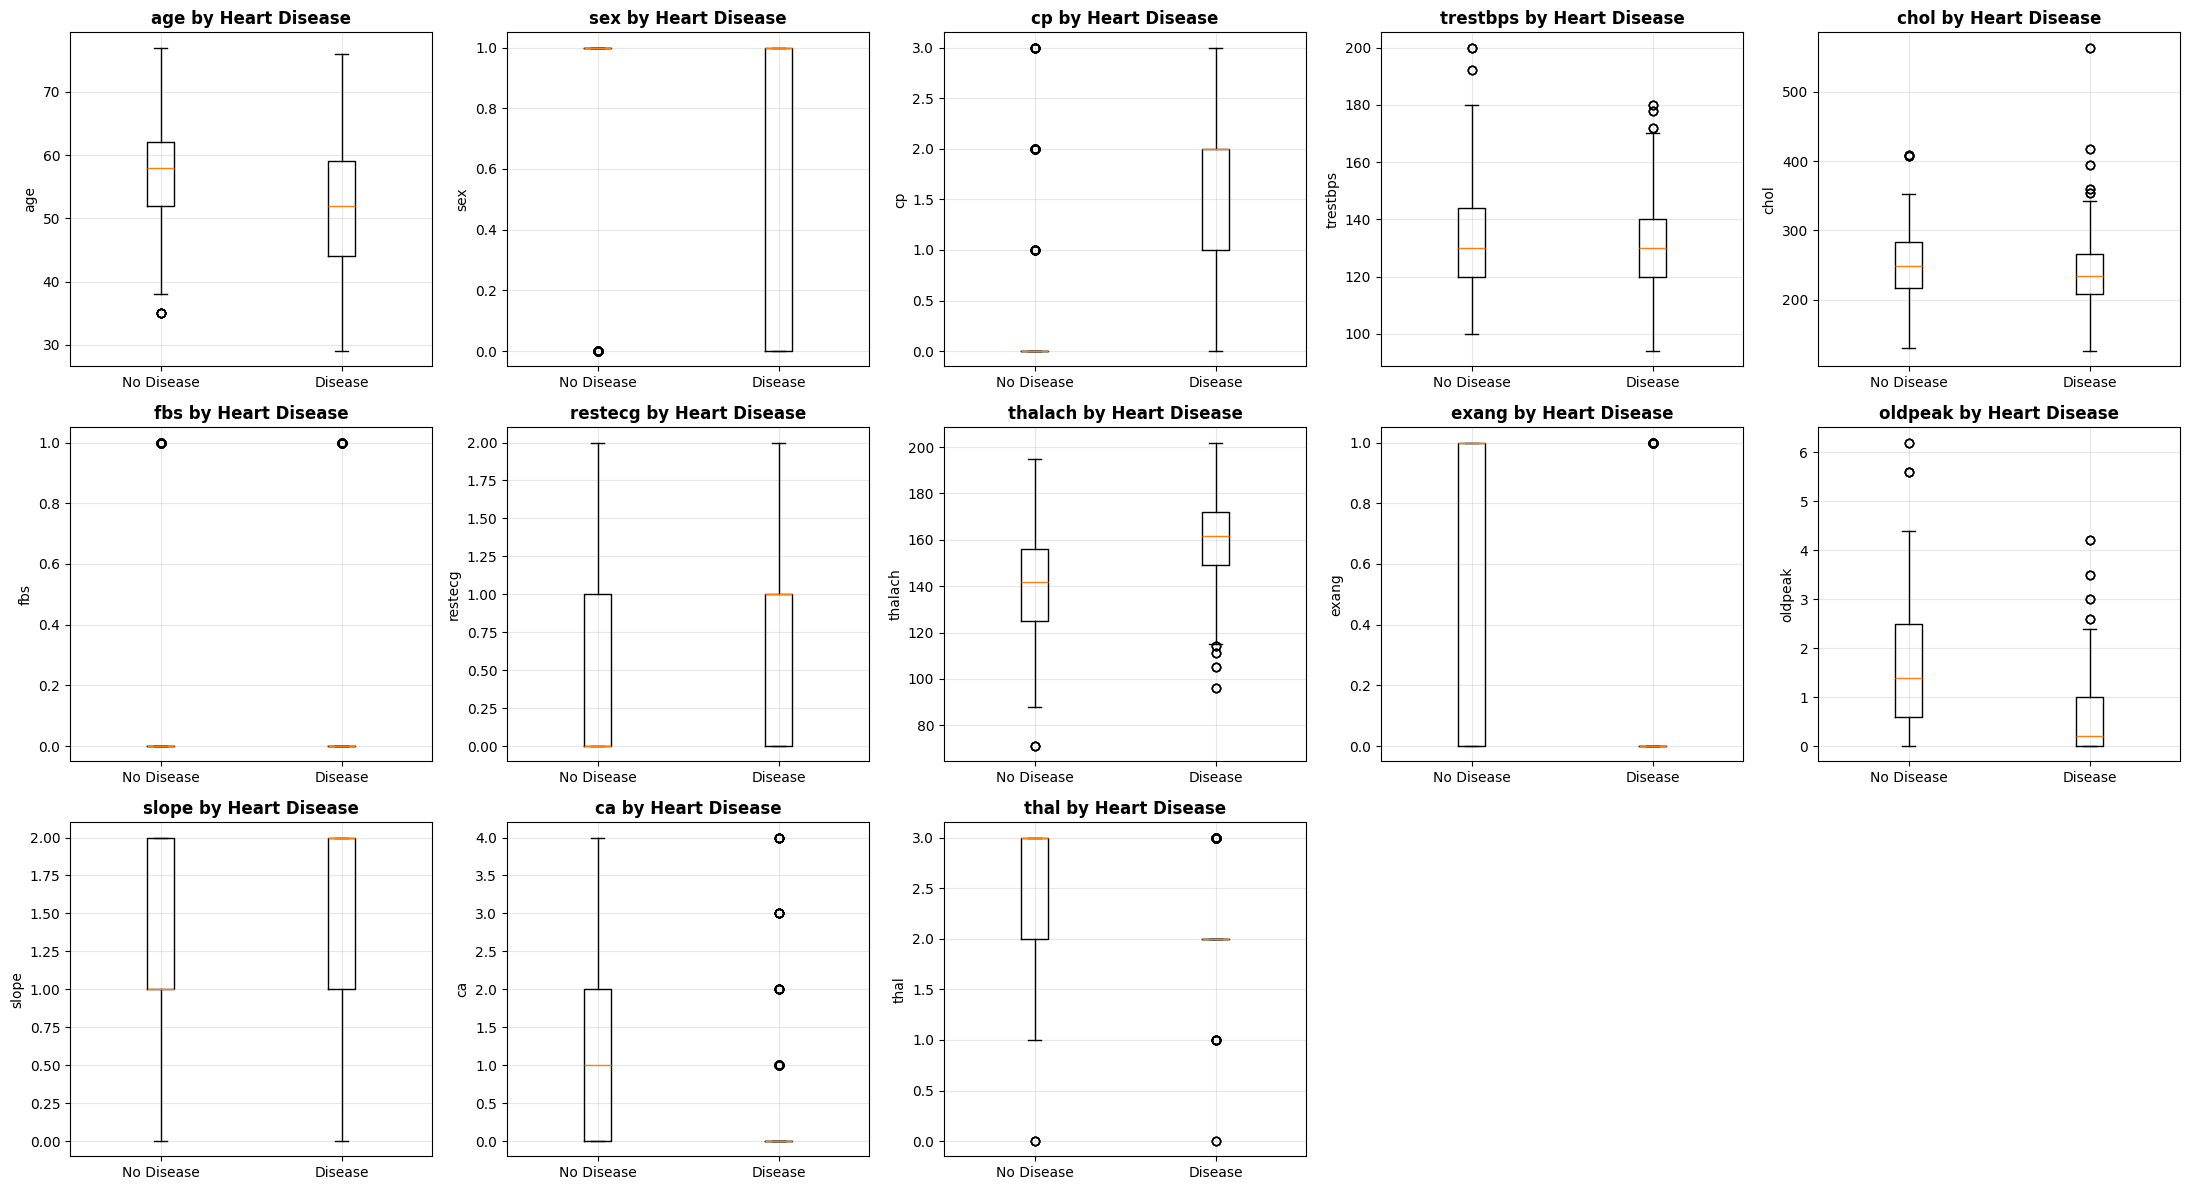

In [24]:
# Visualization 4: Feature Comparison by Target
fig, axes = plt.subplots(3, 5, figsize=(22, 12))
features = ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 
            'exang', 'oldpeak', 'slope', 'ca', 'thal']

for idx, feature in enumerate(features):
    row = idx // 5
    col = idx % 5
    
    no_disease = df[df['target'] == 0][feature]
    disease = df[df['target'] == 1][feature]
    
    axes[row, col].boxplot([no_disease, disease], labels=['No Disease', 'Disease'])
    axes[row, col].set_title(f'{feature} by Heart Disease', fontweight='bold')
    axes[row, col].set_ylabel(feature)
    axes[row, col].grid(alpha=0.3)

# Remove empty subplots
fig.delaxes(axes[2, 3])
fig.delaxes(axes[2, 4])
plt.tight_layout()
plt.show()

In [25]:
# Data Preprocessing: Separate Features and Target
X = df.drop('target', axis=1)
y = df['target']

print("Features Shape:", X.shape)
print("Target Shape:", y.shape)
print("\nFeature Columns:", X.columns.tolist())
print("\nTarget Value Counts:")
print(y.value_counts())

Features Shape: (1025, 13)
Target Shape: (1025,)

Feature Columns: ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal']

Target Value Counts:
target
1    526
0    499
Name: count, dtype: int64


In [26]:
# Split Data into Training and Testing Sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("Training Set Size:", X_train.shape)
print("Testing Set Size:", X_test.shape)
print("\nTraining Target Distribution:")
print(y_train.value_counts().head(10))

Training Set Size: (820, 13)
Testing Set Size: (205, 13)

Training Target Distribution:
target
1    421
0    399
Name: count, dtype: int64


In [27]:
# Build and Train Decision Tree Classifier
dt_model = DecisionTreeClassifier(
    criterion='entropy',      # Use entropy for information gain
    max_depth=10,            # Limit tree depth to prevent overfitting
    min_samples_split=5,     # Minimum samples required to split a node
    min_samples_leaf=2,      # Minimum samples required at leaf node
    random_state=42
)

# Train the model
dt_model.fit(X_train, y_train)
print("Decision Tree Model trained successfully!")
print(f"\nTree Depth: {dt_model.get_depth()}")
print(f"Number of Leaves: {dt_model.get_n_leaves()}")

Decision Tree Model trained successfully!

Tree Depth: 9
Number of Leaves: 49


In [28]:
# Make Predictions on Training and Testing Sets
y_train_pred = dt_model.predict(X_train)
y_test_pred = dt_model.predict(X_test)

# Calculate Accuracies
train_accuracy = accuracy_score(y_train, y_train_pred)
test_accuracy = accuracy_score(y_test, y_test_pred)

print(f"Training Accuracy: {train_accuracy * 100:.2f}%")
print(f"Testing Accuracy: {test_accuracy * 100:.2f}%")

Training Accuracy: 99.39%
Testing Accuracy: 94.63%


In [29]:
# Classification Report
print("Classification Report for Test Set:\n")
print(classification_report(y_test, y_test_pred))

Classification Report for Test Set:

              precision    recall  f1-score   support

           0       0.96      0.93      0.94       100
           1       0.94      0.96      0.95       105

    accuracy                           0.95       205
   macro avg       0.95      0.95      0.95       205
weighted avg       0.95      0.95      0.95       205



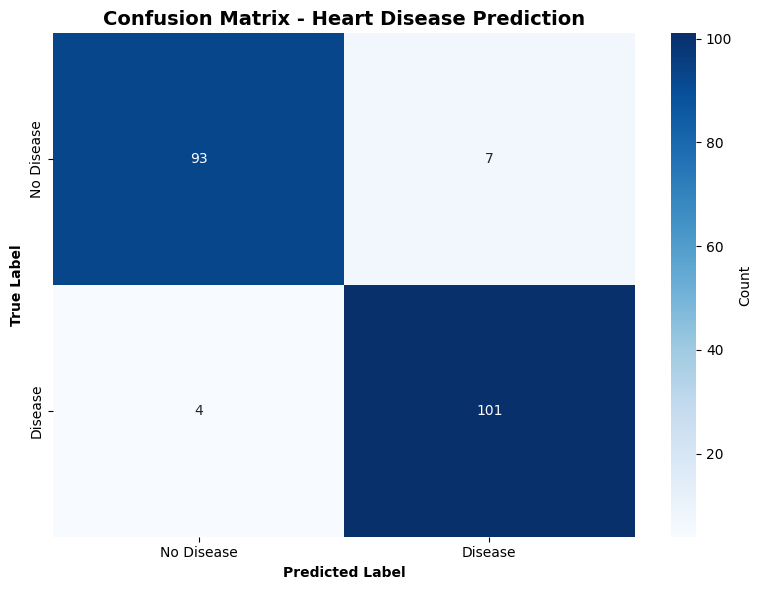


Precision: 0.9352
Recall: 0.9619
F1-Score: 0.9484


In [30]:
# Confusion Matrix Visualization
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_test_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['No Disease', 'Disease'], 
            yticklabels=['No Disease', 'Disease'],
            cbar_kws={'label': 'Count'})
plt.title('Confusion Matrix - Heart Disease Prediction', fontsize=14, fontweight='bold')
plt.xlabel('Predicted Label', fontweight='bold')
plt.ylabel('True Label', fontweight='bold')
plt.tight_layout()
plt.show()

# Calculate additional metrics
from sklearn.metrics import precision_score, recall_score, f1_score
print(f"\nPrecision: {precision_score(y_test, y_test_pred):.4f}")
print(f"Recall: {recall_score(y_test, y_test_pred):.4f}")
print(f"F1-Score: {f1_score(y_test, y_test_pred):.4f}")

Feature Importance:
     Feature  Importance
2         cp    0.234241
0        age    0.120160
11        ca    0.118737
4       chol    0.107246
9    oldpeak    0.097156
12      thal    0.095208
1        sex    0.052019
6    restecg    0.050478
3   trestbps    0.046552
7    thalach    0.038869
8      exang    0.023833
10     slope    0.015500
5        fbs    0.000000


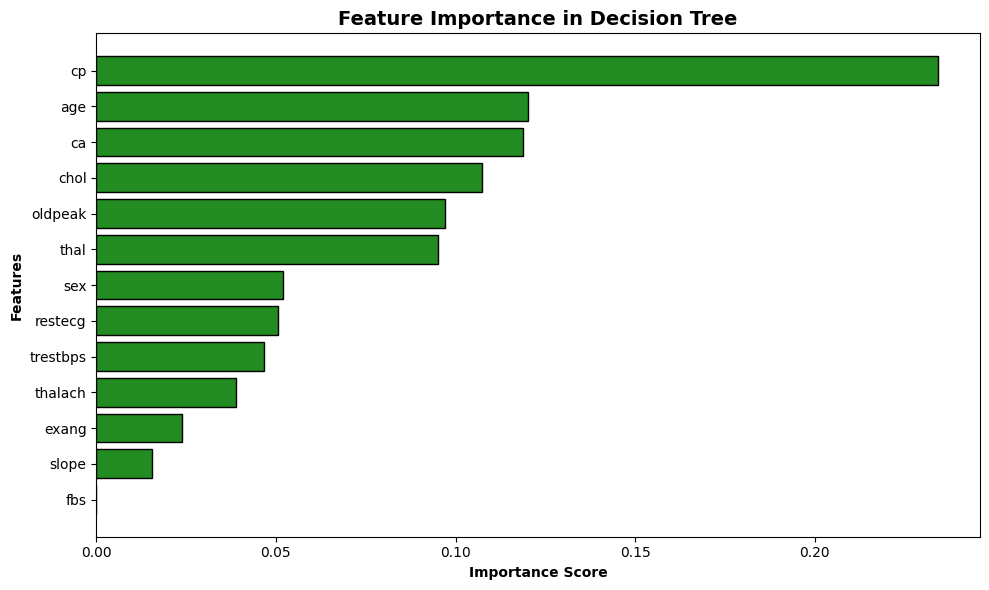

In [31]:
# Feature Importance
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': dt_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

print("Feature Importance:")
print(feature_importance)

# Visualize Feature Importance
plt.figure(figsize=(10, 6))
plt.barh(feature_importance['Feature'], feature_importance['Importance'], color='forestgreen', edgecolor='black')
plt.xlabel('Importance Score', fontweight='bold')
plt.ylabel('Features', fontweight='bold')
plt.title('Feature Importance in Decision Tree', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [32]:
# Cross-Validation Score
cv_scores = cross_val_score(dt_model, X, y, cv=5, scoring='accuracy')
print(f"Cross-Validation Scores: {cv_scores}")
print(f"Mean CV Accuracy: {cv_scores.mean() * 100:.2f}%")
print(f"Standard Deviation: {cv_scores.std() * 100:.2f}%")

Cross-Validation Scores: [1.         0.96585366 0.95609756 0.9902439  0.9804878 ]
Mean CV Accuracy: 97.85%
Standard Deviation: 1.59%


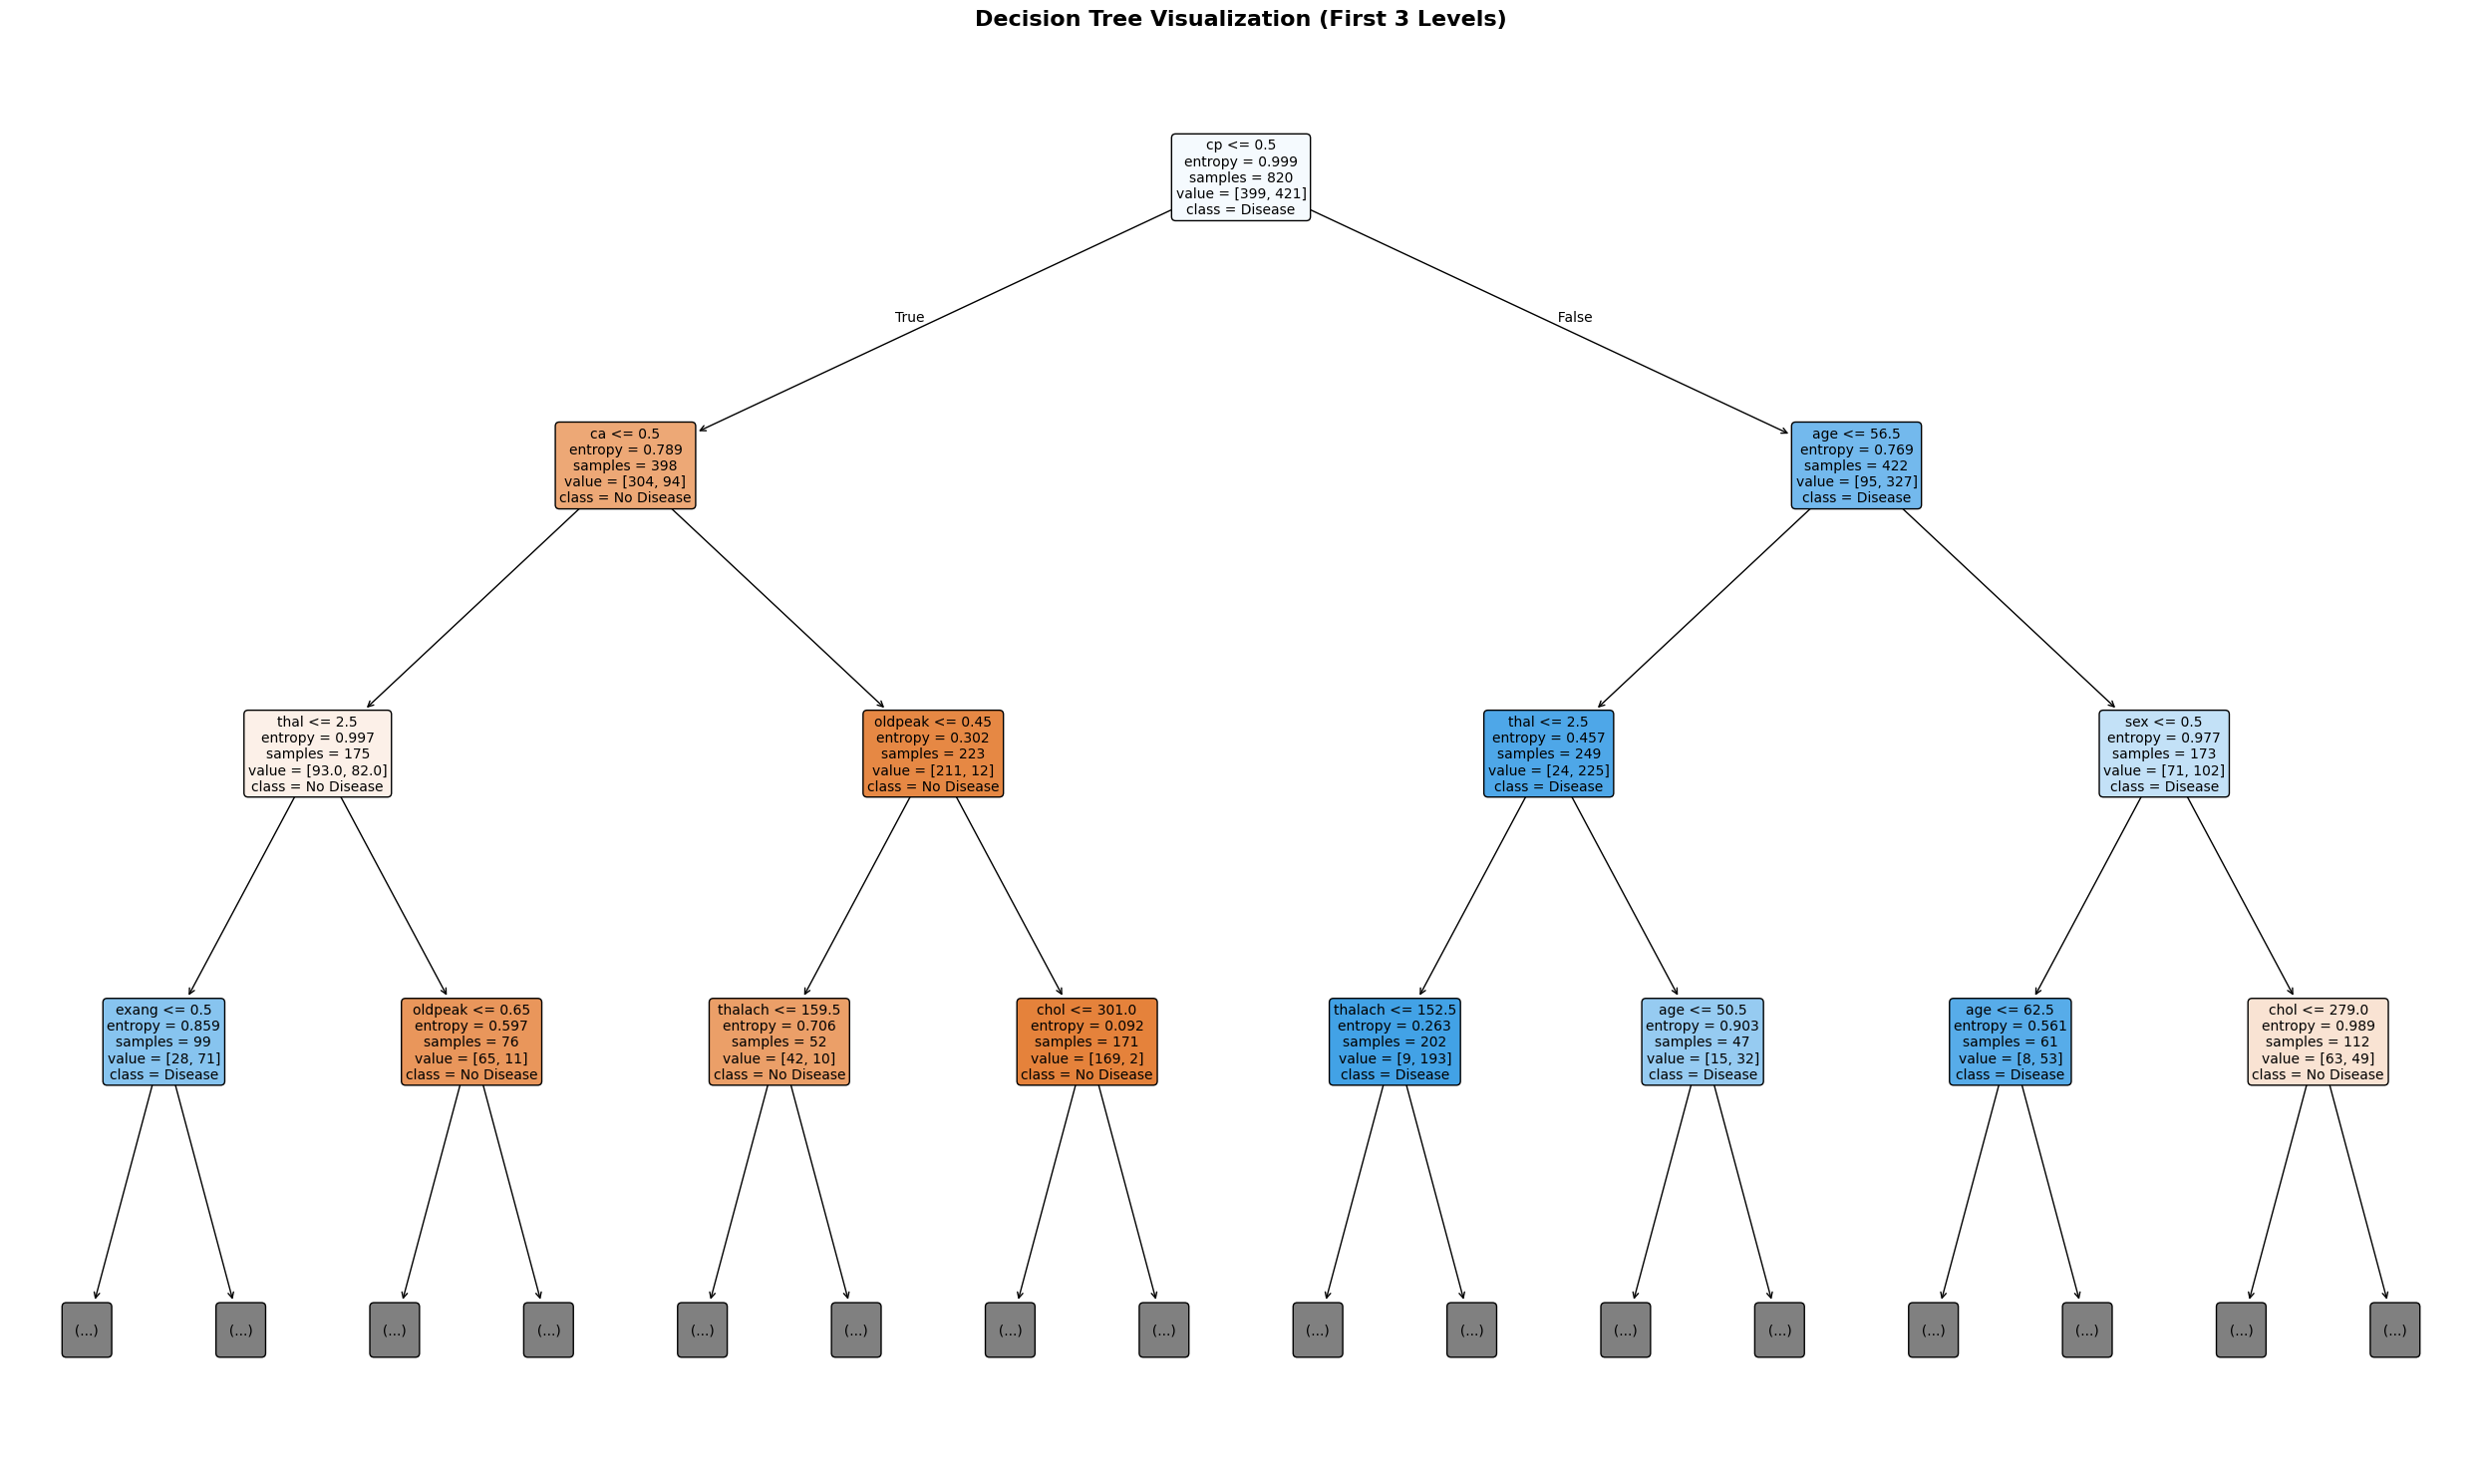

In [35]:
# Visualize Decision Tree (Simplified view with max_depth=3)
plt.figure(figsize=(25, 15))
plot_tree(
    dt_model,
    feature_names=X.columns,
    class_names=['No Disease', 'Disease'],  # Convert to string labels
    filled=True,
    rounded=True,
    fontsize=10,
    max_depth=3  # Show only first 3 levels for better visualization
)
plt.title('Decision Tree Visualization (First 3 Levels)', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

In [38]:
# Test with Real Samples from the Dataset
# Pick one patient with disease and one without disease
sample_disease = df[df['target'] == 1].iloc[0]
sample_no_disease = df[df['target'] == 0].iloc[0]

X_disease = sample_disease.drop('target').to_frame().T
X_no_disease = sample_no_disease.drop('target').to_frame().T

pred_disease = dt_model.predict(X_disease)[0]
prob_disease = dt_model.predict_proba(X_disease)[0]

pred_no_disease = dt_model.predict(X_no_disease)[0]
prob_no_disease = dt_model.predict_proba(X_no_disease)[0]

print("Sample A - Known Disease (target=1):")
print(X_disease)
print(f"Predicted: {'Heart Disease' if pred_disease == 1 else 'No Heart Disease'}")
print(f"Probability: No Disease={prob_disease[0]:.2%}, Disease={prob_disease[1]:.2%}\n")

print("Sample B - Known No Disease (target=0):")
print(X_no_disease)
print(f"Predicted: {'Heart Disease' if pred_no_disease == 1 else 'No Heart Disease'}")
print(f"Probability: No Disease={prob_no_disease[0]:.2%}, Disease={prob_no_disease[1]:.2%}")

Sample A - Known Disease (target=1):
    age  sex   cp  trestbps   chol  fbs  restecg  thalach  exang  oldpeak  \
5  58.0  0.0  0.0     100.0  248.0  0.0      0.0    122.0    0.0      1.0   

   slope   ca  thal  
5    1.0  0.0   2.0  
Predicted: Heart Disease
Probability: No Disease=0.00%, Disease=100.00%

Sample B - Known No Disease (target=0):
    age  sex   cp  trestbps   chol  fbs  restecg  thalach  exang  oldpeak  \
0  52.0  1.0  0.0     125.0  212.0  0.0      1.0    168.0    0.0      1.0   

   slope   ca  thal  
0    2.0  2.0   3.0  
Predicted: No Heart Disease
Probability: No Disease=100.00%, Disease=0.00%
